# Final Code - Multi-scenario wheel comparison - With timestamps

In [85]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the Final Data folder relative to this notebook location
candidate_dirs = [
    Path.cwd() / "Final Data",
    Path.cwd().parent / "Final Data",
    Path.cwd() / "Data",
    Path.cwd().parent / "Data",
]
data_dir = next((p for p in candidate_dirs if p.exists()), None)
if data_dir is None:
    raise FileNotFoundError("Could not find a 'Final Data' folder next to this notebook.")

expected_cols = ["time_ms", "epoch_ms", "iso_time", "current_mA", "voltage_V", "power_W", "energy_J"]
terrain_labels = {
    "baseline": "Flat road (Baseline)",
    "gravel": "Flat gravel",
    "hill": "Slope (gravel)",
    "grass": "Grass (Uneven terrain)",
    "sand": "Beach (Sand)",
    "shells": "Beach (Shells)",
    "step": "Steps",
}
terrain_order = ["baseline", "gravel", "hill", "grass", "sand", "shells", "step"]


def parse_metadata(file_name: str) -> tuple[str, str, str, int | None]:
    name = file_name.lower().replace(".csv", "")
    wheel_state = "open" if "_open_" in name else "closed"
    direction = "reverse" if "reverse" in name else "forward"
    if "_baseline_" in name:
        terrain_key = "baseline"
    elif "_hill_" in name:
        terrain_key = "hill"
    elif "_gravel_" in name:
        terrain_key = "gravel"
    elif "_grass_" in name:
        terrain_key = "grass"
    elif "_sand_" in name:
        terrain_key = "sand"
    elif "_shells_" in name:
        terrain_key = "shells"
    elif "_step_" in name:
        terrain_key = "step"
    else:
        terrain_key = "other"

    rep_token = name.split("_")[-1]
    repetition = int(rep_token) if rep_token.isdigit() else None
    return wheel_state, direction, terrain_key, repetition


records = []
for csv_path in sorted(data_dir.glob("*.csv")):
    if "wheel" not in csv_path.name.lower():
        continue

    run_df = pd.read_csv(csv_path)
    run_df.columns = [c.strip() for c in run_df.columns]

    if not all(col in run_df.columns for col in expected_cols):
        run_df = pd.read_csv(
            csv_path,
            names=expected_cols,
            header=0,
            comment="~",
            on_bad_lines="skip",
        )

    for numeric_col in ["time_ms", "epoch_ms", "current_mA", "voltage_V", "power_W", "energy_J"]:
        if numeric_col in run_df.columns:
            run_df[numeric_col] = pd.to_numeric(run_df[numeric_col], errors="coerce")
    run_df = run_df.dropna(subset=["time_ms", "current_mA", "voltage_V", "power_W", "energy_J"])
    run_df = run_df.dropna(subset=["time_ms", "current_mA", "voltage_V", "power_W", "energy_J"])

    wheel_state, direction, terrain_key, repetition = parse_metadata(csv_path.name)
    run_df["file"] = csv_path.name
    run_df["wheel_state"] = wheel_state
    run_df["direction"] = direction
    run_df["terrain_key"] = terrain_key
    run_df["terrain"] = terrain_labels.get(terrain_key, terrain_key)
    run_df["repetition"] = repetition
    run_df["time_s"] = run_df["time_ms"] / 1000.0
    run_df["real_time"] = pd.to_datetime(run_df["iso_time"], errors="coerce") if "iso_time" in run_df.columns else pd.to_datetime(run_df["epoch_ms"], unit="ms", errors="coerce")
    records.append(run_df)

if not records:
    raise ValueError("No wheel CSV files were found in the Final Data folder.")
all_data = pd.concat(records, ignore_index=True)

display(all_data.head())

print(f"Loaded {all_data['file'].nunique()} files from: {data_dir}")
print("Terrains found:", sorted(all_data["terrain_key"].dropna().unique().tolist()))

,time_ms,epoch_ms,iso_time,current_mA,voltage_V,power_W,energy_J,file,wheel_state,direction,terrain_key,terrain,repetition,time_s,real_time
0,4,1780302095682,2026-06-01 10:21:35.682,0.000,12.368,0.000,0.000,Data_Wheel_baseline_closed.csv,closed,forward,baseline,Flat road (Baseline),None,0.004,2026-06-01 10:21:35.682
1,64,1780302095742,2026-06-01 10:21:35.742,0.300,12.368,0.004,0.000,Data_Wheel_baseline_closed.csv,closed,forward,baseline,Flat road (Baseline),None,0.064,2026-06-01 10:21:35.742
2,115,1780302095793,2026-06-01 10:21:35.793,0.100,12.368,0.001,0.000,Data_Wheel_baseline_closed.csv,closed,forward,baseline,Flat road (Baseline),None,0.115,2026-06-01 10:21:35.793
3,167,1780302095845,2026-06-01 10:21:35.845,0.100,12.412,0.001,0.000,Data_Wheel_baseline_closed.csv,closed,forward,baseline,Flat road (Baseline),None,0.167,2026-06-01 10:21:35.845
4,227,1780302095905,2026-06-01 10:21:35.905,0.100,12.368,0.001,0.000,Data_Wheel_baseline_closed.csv,closed,forward,baseline,Flat road (Baseline),None,0.227,2026-06-01 10:21:35.905


Loaded 39 files from: c:\Users\gomop\Desktop\GM MA4\Projet de Semestre II\Code\Final Data
Terrains found: ['baseline', 'grass', 'gravel', 'hill', 'sand', 'shells', 'step']


In [86]:
def extract_analysis_window(run_df: pd.DataFrame, analysis_seconds: float = 8.0, spike_fraction: float = 0.35, min_consecutive: int = 3) -> tuple[pd.DataFrame, float, float]:
    run_df = run_df.sort_values("time_s").reset_index(drop=True)

    current = run_df["current_mA"].to_numpy(dtype=float)
    peak_idx = int(np.nanargmax(current))
    peak_value = float(current[peak_idx])
    median_value = float(np.nanmedian(current))
    threshold = max(median_value * 2.0, peak_value * spike_fraction)

    start_idx = peak_idx
    below_count = 0
    for idx in range(peak_idx, len(run_df)):
        if float(run_df.loc[idx, "current_mA"]) <= threshold:
            below_count += 1
            if below_count >= min_consecutive:
                start_idx = idx - min_consecutive + 1
                break
        else:
            below_count = 0

    start_time_s = float(run_df.loc[start_idx, "time_s"])
    end_time_s = min(start_time_s + analysis_seconds, float(run_df["time_s"].iloc[-1]))

    window_df = run_df[(run_df["time_s"] >= start_time_s) & (run_df["time_s"] <= end_time_s)].copy()
    window_df["time_s_window"] = window_df["time_s"] - start_time_s

    return window_df, start_time_s, end_time_s


def analyze_terrain(terrain_key: str, analysis_seconds: float = 8.0):
    terrain_df = all_data[all_data["terrain_key"] == terrain_key].copy()
    if terrain_df.empty:
        print(f"No files found for terrain: {terrain_key}")
        return

    run_rows = []
    run_windows = []

    for file_name, g in terrain_df.groupby("file"):
        window_df, start_time_s, end_time_s = extract_analysis_window(g, analysis_seconds=analysis_seconds)
        if window_df.empty:
            continue

        wheel_state = window_df["wheel_state"].iloc[0]
        direction = window_df["direction"].iloc[0]
        repetition = window_df["repetition"].iloc[0]

        dt = window_df["time_s_window"].diff().fillna(0.0)
        energy_from_power_J = float((window_df["power_W"] * dt).sum())
        energy_window_J = float(window_df["energy_J"].iloc[-1] - window_df["energy_J"].iloc[0])

        run_rows.append(
            {
                "terrain": window_df["terrain"].iloc[0],
                "file": file_name,
                "configuration": f"{wheel_state}{' reverse' if direction == 'reverse' else ''}",
                "wheel_state": wheel_state,
                "direction": direction,
                "repetition": repetition,
                "analysis_start_s": start_time_s,
                "analysis_end_s": end_time_s,
                "analysis_start_time": window_df["real_time"].iloc[0],
                "analysis_end_time": window_df["real_time"].iloc[-1],
                "window_duration_s": float(window_df["time_s_window"].iloc[-1]),
                "current_avg_A": float(window_df["current_mA"].mean() / 1000.0),
                "power_avg_W": float(window_df["power_W"].mean()),
                "energy_J": energy_window_J,
                "energy_from_power_J": energy_from_power_J,
            }
        )
        run_windows.append((file_name, window_df))

    summary_df = pd.DataFrame(run_rows)
    if summary_df.empty:
        print(f"No valid windows found for terrain: {terrain_key}")
        return

    summary_df = summary_df.sort_values(["wheel_state", "direction", "repetition"]).reset_index(drop=True)
    display(summary_df)

    print(f"Averages for {terrain_labels.get(terrain_key, terrain_key)}:")
    config_summary = (
        summary_df.groupby(["wheel_state", "direction"], as_index=False)
        .agg(
            runs=("file", "count"),
            current_avg_A=("current_avg_A", "mean"),
            power_avg_W=("power_avg_W", "mean"),
            energy_J=("energy_J", "mean"),
            energy_from_power_J=("energy_from_power_J", "mean"),
            window_duration_s=("window_duration_s", "mean"),
        )
    )
    config_summary["configuration"] = config_summary.apply(
        lambda row: f"{row['wheel_state']}{' reverse' if row['direction'] == 'reverse' else ''}", axis=1
    )
    config_summary = config_summary[["configuration", "runs", "current_avg_A", "power_avg_W", "energy_J", "energy_from_power_J", "window_duration_s"]]
    display(config_summary)

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for file_name, window_df in run_windows:
        label = file_name.replace("Data_Wheel_", "").replace(".csv", "")
        axes[0].plot(window_df["time_s_window"], window_df["current_mA"], label=label)
        axes[1].plot(window_df["time_s_window"], window_df["energy_J"], label=label)

    axes[0].set_ylabel("Current (mA)")
    axes[0].set_title(f"{terrain_labels.get(terrain_key, terrain_key)} - Current over analysis window")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel("Energy (J)")
    axes[1].set_xlabel("Time after analysis start (s)")
    axes[1].set_title(f"{terrain_labels.get(terrain_key, terrain_key)} - Energy over analysis window")
    axes[1].grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

    return summary_df, config_summary

Flat gravel


,terrain,file,configuration,wheel_state,direction,repetition,analysis_start_s,analysis_end_s,analysis_start_time,analysis_end_time,window_duration_s,current_avg_A,power_avg_W,energy_J,energy_from_power_J
0,Flat gravel,Data_Wheel_closed_gravel_1.csv,closed,closed,forward,1,2.188,10.188,2026-05-20 18:00:14.511,2026-05-20 18:00:22.493,7.982,0.091,1.124,8.821,8.821
1,Flat gravel,Data_Wheel_closed_gravel_2.csv,closed,closed,forward,2,2.254,10.254,2026-05-20 18:01:38.962,2026-05-20 18:01:46.948,7.986,0.089,1.093,8.633,8.633
2,Flat gravel,Data_Wheel_open_gravel_1.csv,open,open,forward,1,1.228,9.228,2026-05-20 17:44:07.698,2026-05-20 17:44:15.655,7.957,0.198,2.366,18.902,18.902
3,Flat gravel,Data_Wheel_open_gravel_2.csv,open,open,forward,2,1.982,9.982,2026-05-20 17:45:20.605,2026-05-20 17:45:28.581,7.976,0.200,2.412,19.058,19.059
4,Flat gravel,Data_Wheel_open_gravel_reverse_1.csv,open reverse,open,reverse,1,2.545,10.545,2026-05-20 17:54:20.642,2026-05-20 17:54:28.615,7.973,0.160,1.941,15.375,15.374
5,Flat gravel,Data_Wheel_open_gravel_reverse_2.csv,open reverse,open,reverse,2,1.916,9.916,2026-05-20 17:55:19.213,2026-05-20 17:55:27.173,7.960,0.158,1.920,15.218,15.218


Averages for Flat gravel:


,configuration,runs,current_avg_A,power_avg_W,energy_J,energy_from_power_J,window_duration_s
0,closed,2,0.090,1.108,8.727,8.727,7.984
1,open,2,0.199,2.389,18.980,18.981,7.966
2,open reverse,2,0.159,1.931,15.297,15.296,7.966


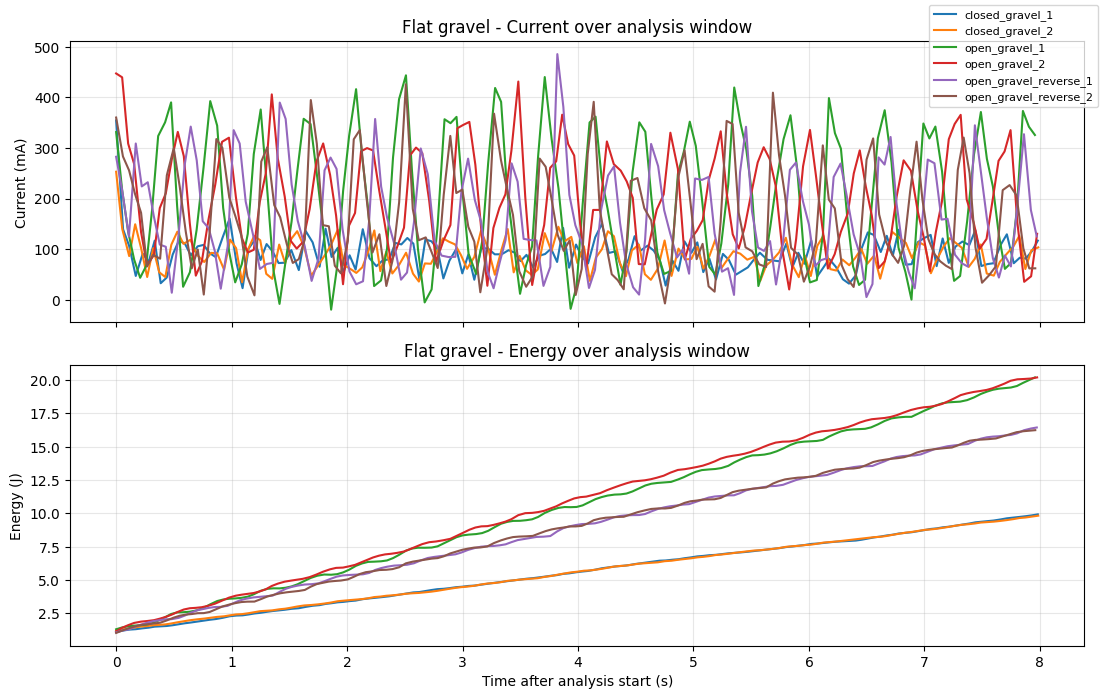

In [87]:
print("Flat gravel")
flat_gravel_summary, flat_gravel_config = analyze_terrain("gravel")

Slope (gravel)


,terrain,file,configuration,wheel_state,direction,repetition,analysis_start_s,analysis_end_s,analysis_start_time,analysis_end_time,window_duration_s,current_avg_A,power_avg_W,energy_J,energy_from_power_J
0,Slope (gravel),Data_Wheel_closed_hill_1.csv,closed,closed,forward,1,1.592,9.592,2026-05-21 10:14:52.565,2026-05-21 10:15:00.537,7.972,0.092,1.132,8.894,8.894
1,Slope (gravel),Data_Wheel_closed_hill_2.csv,closed,closed,forward,2,2.808,10.808,2026-05-21 10:15:34.955,2026-05-21 10:15:42.936,7.981,0.098,1.206,9.493,9.494
2,Slope (gravel),Data_Wheel_open_hill_1.csv,open,open,forward,1,1.710,9.710,2026-05-21 10:34:54.695,2026-05-21 10:35:02.670,7.975,0.206,2.453,19.453,19.453
3,Slope (gravel),Data_Wheel_open_hill_2.csv,open,open,forward,2,3.120,11.120,2026-05-21 10:35:28.897,2026-05-21 10:35:36.858,7.961,0.220,2.614,20.646,20.646
4,Slope (gravel),Data_Wheel_open_hill_reverse_1.csv,open reverse,open,reverse,1,2.497,10.497,2026-05-21 10:23:23.246,2026-05-21 10:23:31.223,7.977,0.185,2.231,17.713,17.713
5,Slope (gravel),Data_Wheel_open_hill_reverse_2.csv,open reverse,open,reverse,2,1.547,9.547,2026-05-21 10:24:15.446,2026-05-21 10:24:23.418,7.972,0.179,2.150,17.052,17.052


Averages for Slope (gravel):


,configuration,runs,current_avg_A,power_avg_W,energy_J,energy_from_power_J,window_duration_s
0,closed,2,0.095,1.169,9.194,9.194,7.976
1,open,2,0.213,2.534,20.050,20.049,7.968
2,open reverse,2,0.182,2.191,17.383,17.382,7.975


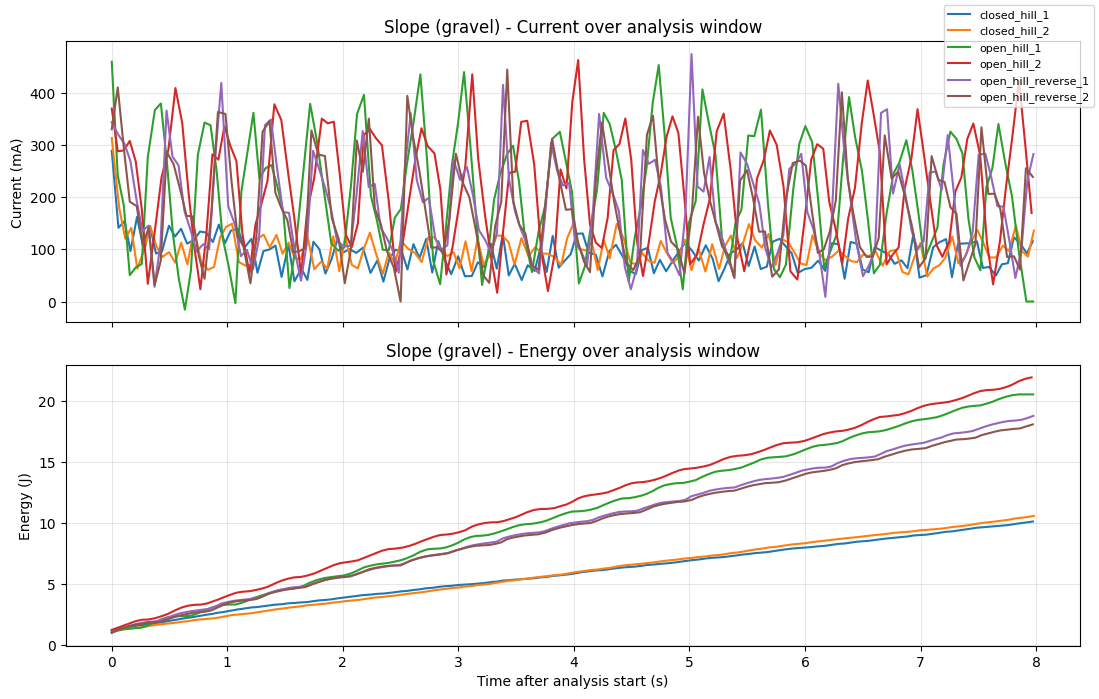

In [88]:
print("Slope (gravel)")
slope_gravel_summary, slope_gravel_config = analyze_terrain("hill")

Grass (Uneven terrain)


,terrain,file,configuration,wheel_state,direction,repetition,analysis_start_s,analysis_end_s,analysis_start_time,analysis_end_time,window_duration_s,current_avg_A,power_avg_W,energy_J,energy_from_power_J
0,Grass (Uneven terrain),Data_Wheel_closed_grass_1.csv,closed,closed,forward,1,2.415,10.415,2026-05-20 17:24:57.363,2026-05-20 17:25:05.331,7.968,0.124,1.534,12.191,12.191
1,Grass (Uneven terrain),Data_Wheel_closed_grass_2.csv,closed,closed,forward,2,3.191,11.191,2026-05-20 17:26:33.391,2026-05-20 17:26:41.352,7.961,0.090,1.113,8.690,8.690
2,Grass (Uneven terrain),Data_Wheel_open_grass_1.csv,open,open,forward,1,2.833,10.833,2026-05-20 17:41:28.884,2026-05-20 17:41:36.871,7.987,0.163,1.949,15.434,15.434
3,Grass (Uneven terrain),Data_Wheel_open_grass_2.csv,open,open,forward,2,1.676,9.676,2026-05-20 17:42:29.114,2026-05-20 17:42:37.075,7.961,0.155,1.883,14.869,14.869
4,Grass (Uneven terrain),Data_Wheel_open_grass_reverse_1.csv,open reverse,open,reverse,1,2.245,10.245,2026-05-20 17:33:00.381,2026-05-20 17:33:08.349,7.968,0.151,1.848,14.506,14.505
5,Grass (Uneven terrain),Data_Wheel_open_grass_reverse_2.csv,open reverse,open,reverse,2,2.273,10.273,2026-05-20 17:34:53.634,2026-05-20 17:35:01.591,7.957,0.137,1.684,13.236,13.236


Averages for Grass (Uneven terrain):


,configuration,runs,current_avg_A,power_avg_W,energy_J,energy_from_power_J,window_duration_s
0,closed,2,0.107,1.324,10.441,10.441,7.964
1,open,2,0.159,1.916,15.151,15.152,7.974
2,open reverse,2,0.144,1.766,13.871,13.871,7.963


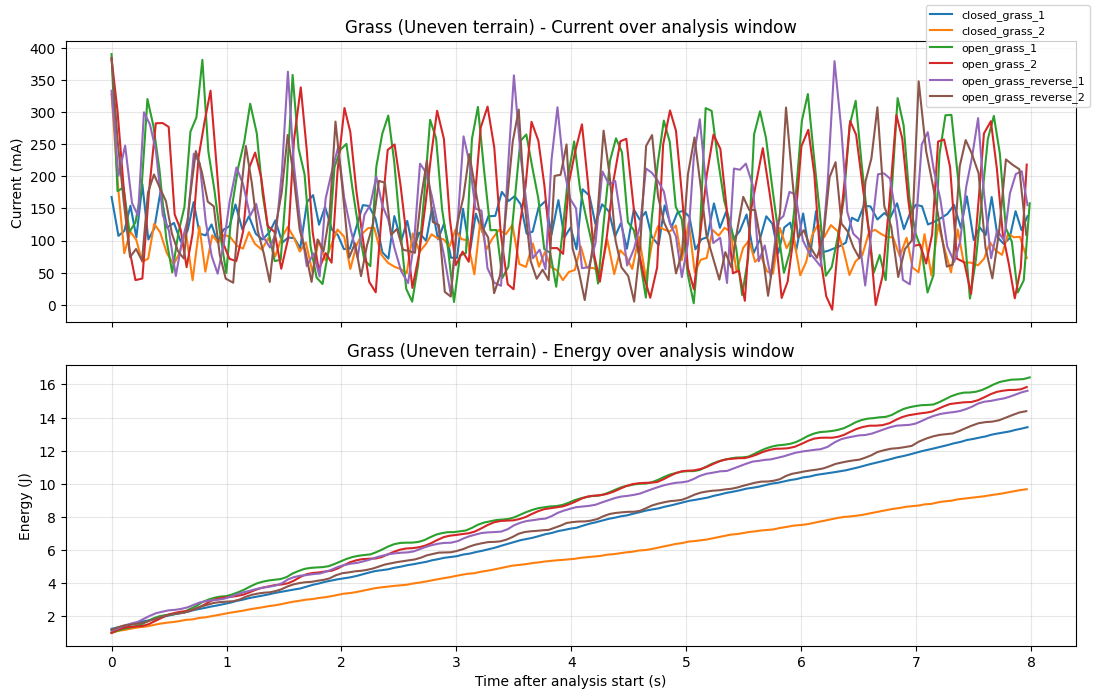

In [89]:
print("Grass (Uneven terrain)")
grass_summary, grass_config = analyze_terrain("grass")

Beach (Sand)


,terrain,file,configuration,wheel_state,direction,repetition,analysis_start_s,analysis_end_s,analysis_start_time,analysis_end_time,window_duration_s,current_avg_A,power_avg_W,energy_J,energy_from_power_J
0,Beach (Sand),Data_Wheel_closed_sand_1.csv,closed,closed,forward,1,5.197,13.197,2026-05-17 14:46:52.786,2026-05-17 14:47:00.751,7.965,0.110,1.310,10.342,10.341
1,Beach (Sand),Data_Wheel_closed_sand_2.csv,closed,closed,forward,2,4.960,12.960,2026-05-17 14:49:45.422,2026-05-17 14:49:53.395,7.973,0.102,1.212,9.450,9.451
2,Beach (Sand),Data_Wheel_open_sand_1.csv,open,open,forward,1,4.255,12.255,2026-05-17 15:08:17.825,2026-05-17 15:08:25.787,7.962,0.182,2.102,16.685,16.685
3,Beach (Sand),Data_Wheel_open_sand_2.csv,open,open,forward,2,4.343,12.343,2026-05-17 15:11:09.512,2026-05-17 15:11:17.511,7.999,0.199,2.299,18.320,18.321
4,Beach (Sand),Data_Wheel_open_sand_reverse_1.csv,open reverse,open,reverse,1,3.870,11.870,2026-05-17 14:59:55.192,2026-05-17 15:00:03.161,7.969,0.186,2.162,17.230,17.230
5,Beach (Sand),Data_Wheel_open_sand_reverse_2.csv,open reverse,open,reverse,2,3.734,11.734,2026-05-17 15:02:04.619,2026-05-17 15:02:12.579,7.960,0.178,2.081,16.391,16.391


Averages for Beach (Sand):


,configuration,runs,current_avg_A,power_avg_W,energy_J,energy_from_power_J,window_duration_s
0,closed,2,0.106,1.261,9.896,9.896,7.969
1,open,2,0.190,2.201,17.502,17.503,7.981
2,open reverse,2,0.182,2.121,16.810,16.811,7.965


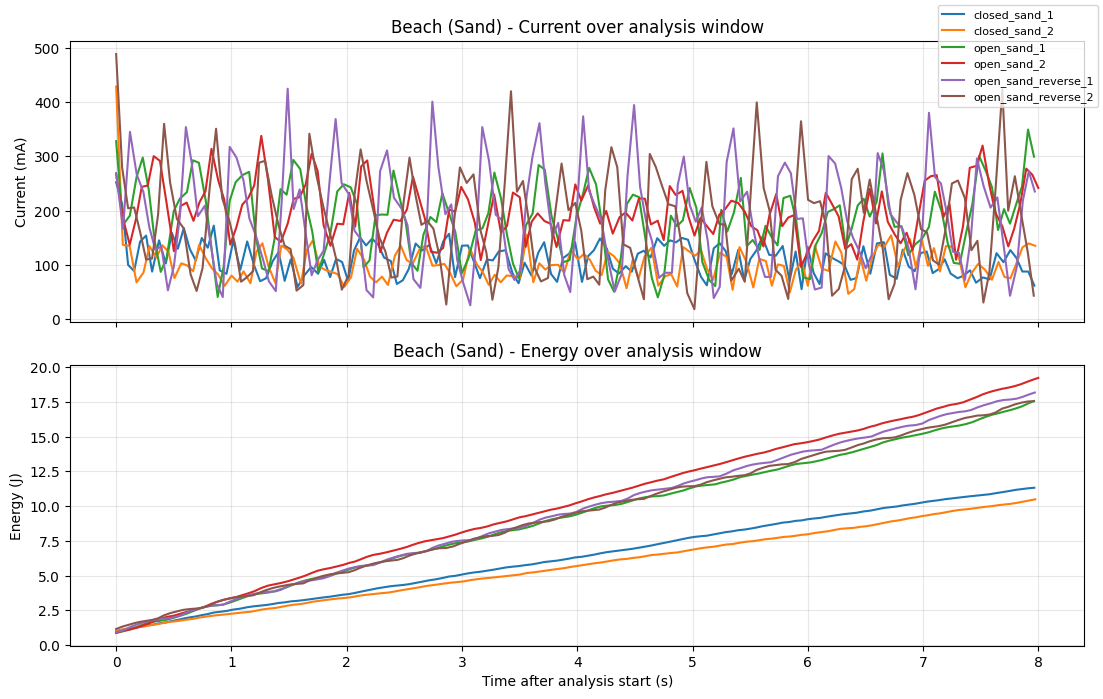

In [90]:
print("Beach (Sand)")
sand_summary, sand_config = analyze_terrain("sand")

Beach (Shells)


,terrain,file,configuration,wheel_state,direction,repetition,analysis_start_s,analysis_end_s,analysis_start_time,analysis_end_time,window_duration_s,current_avg_A,power_avg_W,energy_J,energy_from_power_J
0,Beach (Shells),Data_Wheel_closed_shells_1.csv,closed,closed,forward,1,3.189,11.189,2026-05-20 10:34:47.676,2026-05-20 10:34:55.632,7.956,0.087,1.081,8.537,8.537
1,Beach (Shells),Data_Wheel_closed_shells_2.csv,closed,closed,forward,2,2.533,10.533,2026-05-20 10:36:12.886,2026-05-20 10:36:20.870,7.984,0.087,1.078,8.488,8.488
2,Beach (Shells),Data_Wheel_open_shells_1.csv,open,open,forward,1,2.749,10.749,2026-05-20 10:44:27.585,2026-05-20 10:44:35.541,7.956,0.187,2.279,17.921,17.921
3,Beach (Shells),Data_Wheel_open_shells_2.csv,open,open,forward,2,2.661,10.661,2026-05-20 10:45:51.686,2026-05-20 10:45:59.646,7.960,0.183,2.226,17.601,17.602
4,Beach (Shells),Data_Wheel_open_shells_reverse_1.csv,open reverse,open,reverse,1,3.830,11.830,2026-05-20 10:55:34.190,2026-05-20 10:55:42.140,7.950,0.160,1.914,15.181,15.181
5,Beach (Shells),Data_Wheel_open_shells_reverse_2.csv,open reverse,open,reverse,2,3.212,11.212,2026-05-20 10:56:53.818,2026-05-20 10:57:01.776,7.958,0.156,1.883,14.827,14.827


Averages for Beach (Shells):


,configuration,runs,current_avg_A,power_avg_W,energy_J,energy_from_power_J,window_duration_s
0,closed,2,0.087,1.080,8.512,8.513,7.970
1,open,2,0.185,2.253,17.761,17.761,7.958
2,open reverse,2,0.158,1.898,15.004,15.004,7.954


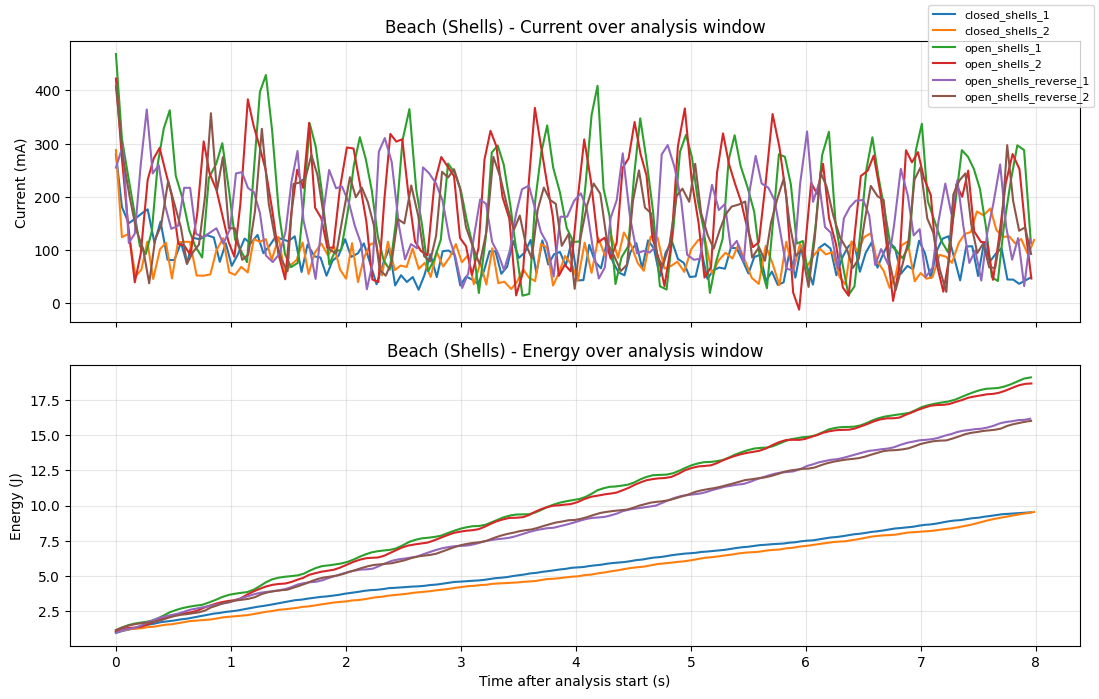

In [91]:
print("Beach (Shells)")
shells_summary, shells_config = analyze_terrain("shells")

Steps


,terrain,file,configuration,wheel_state,direction,repetition,analysis_start_s,analysis_end_s,analysis_start_time,analysis_end_time,window_duration_s,current_avg_A,power_avg_W,energy_J,energy_from_power_J
0,Steps,Data_Wheel_closed_step_1.csv,closed,closed,forward,1,2.408,10.408,2026-05-21 10:12:01.247,2026-05-21 10:12:09.238,7.991,0.133,1.639,12.964,12.964
1,Steps,Data_Wheel_closed_step_2.csv,closed,closed,forward,2,3.602,11.602,2026-05-21 10:13:08.383,2026-05-21 10:13:16.342,7.959,0.129,1.584,12.453,12.454
2,Steps,Data_Wheel_open_step_1.csv,open,open,forward,1,4.203,12.203,2026-05-21 10:29:09.558,2026-05-21 10:29:17.546,7.988,0.192,2.287,18.211,18.211
3,Steps,Data_Wheel_open_step_2.csv,open,open,forward,2,2.581,10.581,2026-05-21 10:33:50.775,2026-05-21 10:33:58.750,7.975,0.156,1.863,14.677,14.678
4,Steps,Data_Wheel_open_step_reverse_1.csv,open reverse,open,reverse,1,2.422,10.422,2026-05-21 10:21:38.047,2026-05-21 10:21:46.042,7.995,0.168,2.035,16.126,16.126
5,Steps,Data_Wheel_open_step_reverse_2.csv,open reverse,open,reverse,2,2.738,10.738,2026-05-21 10:22:29.402,2026-05-21 10:22:37.389,7.987,0.132,1.597,12.579,12.579


Averages for Steps:


,configuration,runs,current_avg_A,power_avg_W,energy_J,energy_from_power_J,window_duration_s
0,closed,2,0.131,1.612,12.709,12.709,7.975
1,open,2,0.174,2.075,16.444,16.444,7.982
2,open reverse,2,0.150,1.816,14.352,14.353,7.991


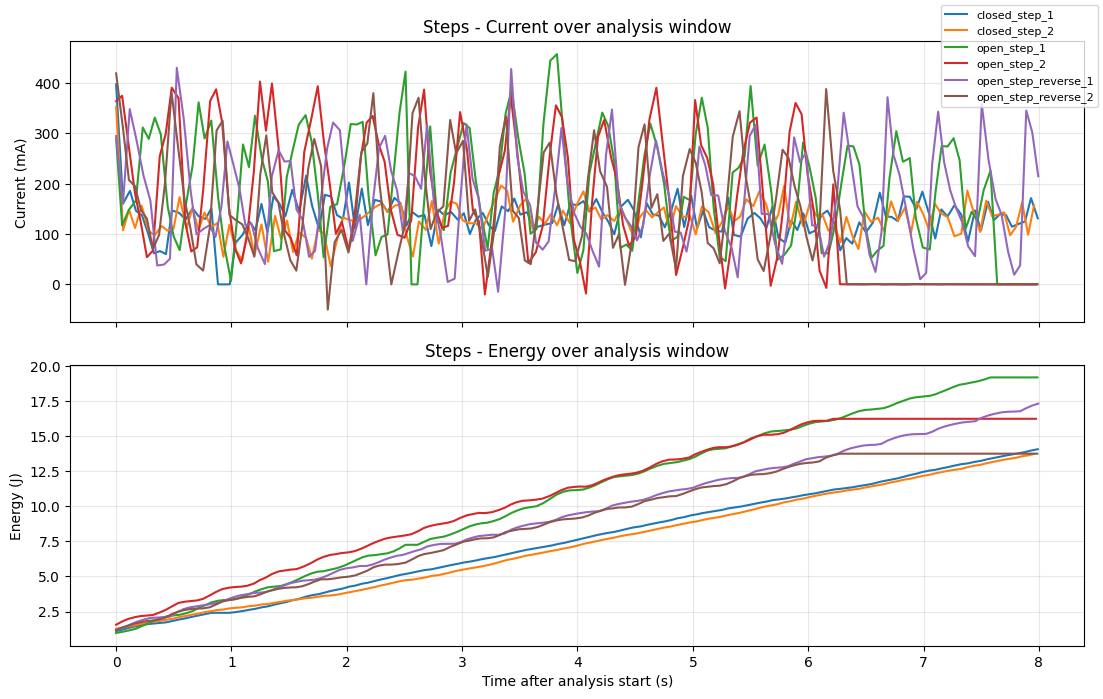

In [92]:
print("Steps")
steps_summary, steps_config = analyze_terrain("step")

Flat road (Baseline)


,terrain,file,configuration,wheel_state,direction,repetition,analysis_start_s,analysis_end_s,analysis_start_time,analysis_end_time,window_duration_s,current_avg_A,power_avg_W,energy_J,energy_from_power_J
0,Flat road (Baseline),Data_Wheel_baseline_closed.csv,closed,closed,forward,None,1.916,9.916,2026-06-01 10:21:37.594,2026-06-01 10:21:45.578,7.984,0.073,0.890,6.933,6.932
1,Flat road (Baseline),Data_Wheel_baseline_open.csv,closed,closed,forward,None,3.067,11.067,2026-06-01 22:12:25.672,2026-06-01 22:12:33.648,7.976,0.194,2.319,18.347,18.347
2,Flat road (Baseline),Data_Wheel_baseline_open_reverse.csv,open reverse,open,reverse,None,3.022,11.022,2026-06-01 22:23:45.647,2026-06-01 22:23:53.625,7.978,0.125,1.508,11.842,11.841


Averages for Flat road (Baseline):


,configuration,runs,current_avg_A,power_avg_W,energy_J,energy_from_power_J,window_duration_s
0,closed,2,0.133,1.605,12.640,12.640,7.980
1,open reverse,1,0.125,1.508,11.842,11.841,7.978


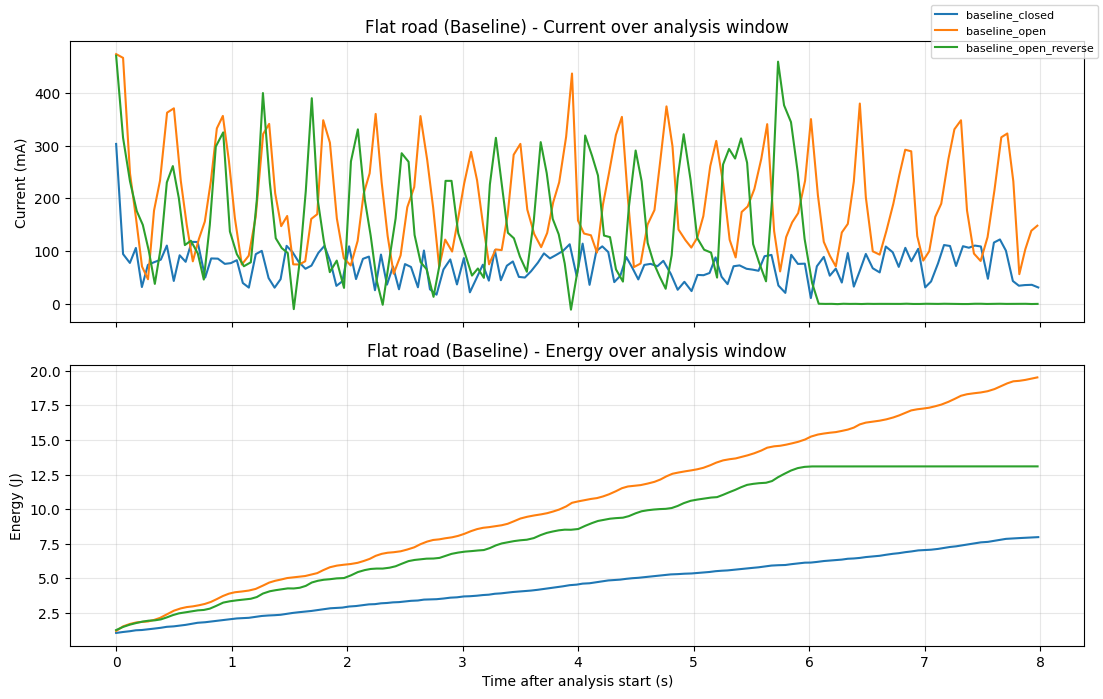

In [93]:
print("Flat road (Baseline)")
baseline_summary, baseline_config = analyze_terrain("baseline")

# Payload Analysis

This section analyses the tests performed with the rover carrying extra loads.
Three terrains were tested (Flat road baseline, Flat gravel, Slope gravel) with three wheel configurations (closed, open, open reverse) and four payload levels: rover only (890 g), +500 g, +890 g, +1 000 g.

**Known failure modes (recorded but rover did not advance):**
- **Open (normal):** belt started skipping teeth for added payload > 500 g — affects all three terrains.
- **Closed on slope:** only worked without extra payload; failed for every added payload level.

Failed runs are loaded and their electrical data is computed, but they are flagged and displayed with a hollow ✕ marker on all plots.

In [94]:
# ─── LOAD PAYLOAD DATA ──────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Find the "Final Data with Payload" folder
candidate_dirs_payload = [
    Path.cwd() / "Final Data with Payload",
    Path.cwd().parent / "Final Data with Payload",
]
payload_data_dir = next((p for p in candidate_dirs_payload if p.exists()), None)
if payload_data_dir is None:
    raise FileNotFoundError("Could not find 'Final Data with Payload' folder next to this notebook.")

ROVER_MASS_G = 890  # grams — rover-only weight

payload_terrain_labels = {
    "baseline": "Flat road (Baseline)",
    "flat":     "Flat gravel",
    "slope":    "Slope (gravel)",
}
PAYLOAD_TERRAIN_ORDER = ["baseline", "flat", "slope"]
CONFIG_ORDER           = ["closed", "open", "open_reverse"]
PAYLOAD_ORDER          = [0, 500, 890, 1000]  # added grams

expected_cols = ["time_ms", "epoch_ms", "iso_time", "current_mA", "voltage_V", "power_W", "energy_J"]


def parse_payload_metadata(file_name: str):
    """
    Parse metadata from payload-test filenames.
    Format: Data_Wheel_{terrain}_{config}[_{added_g}].csv
      terrain  : baseline | flat | slope
      config   : closed | open | open_reverse
      added_g  : 500 | 890 | 1000  (absent → 0, i.e. rover weight only)
    """
    name = file_name.lower().replace(".csv", "")
    if name.startswith("data_wheel_"):
        name = name[len("data_wheel_"):]

    parts = name.split("_")

    # Last token numeric → added payload
    if parts and parts[-1].isdigit():
        added_payload_g = int(parts[-1])
        parts = parts[:-1]
    else:
        added_payload_g = 0

    # First token → terrain
    terrain_key = parts[0] if parts else "unknown"
    parts = parts[1:]

    # Remaining tokens → configuration
    remaining = "_".join(parts)
    if "reverse" in remaining:
        config = "open_reverse"
    elif "open" in remaining:
        config = "open"
    elif "closed" in remaining:
        config = "closed"
    else:
        config = "unknown"

    total_mass_g = ROVER_MASS_G + added_payload_g
    return terrain_key, config, added_payload_g, total_mass_g


def is_failed_run(terrain_key: str, config: str, added_payload_g: int) -> bool:
    """
    Return True for configurations that got stuck during testing.
      - open (normal)  : belt skipped teeth for added payload > 500 g (all terrains)
      - closed on slope: failed for any added payload > 0 g
    """
    if config == "open" and added_payload_g > 500:
        return True
    if config == "closed" and terrain_key == "slope" and added_payload_g > 0:
        return True
    return False


# Load all payload CSV files
payload_records = []
for csv_path in sorted(payload_data_dir.glob("*.csv")):
    if "wheel" not in csv_path.name.lower():
        continue

    run_df = pd.read_csv(csv_path)
    run_df.columns = [c.strip() for c in run_df.columns]

    if not all(col in run_df.columns for col in expected_cols):
        run_df = pd.read_csv(
            csv_path,
            names=expected_cols,
            header=0,
            comment="~",
            on_bad_lines="skip",
        )

    for numeric_col in ["time_ms", "epoch_ms", "current_mA", "voltage_V", "power_W", "energy_J"]:
        if numeric_col in run_df.columns:
            run_df[numeric_col] = pd.to_numeric(run_df[numeric_col], errors="coerce")
    run_df = run_df.dropna(subset=["time_ms", "current_mA", "voltage_V", "power_W", "energy_J"])

    terrain_key, config, added_payload_g, total_mass_g = parse_payload_metadata(csv_path.name)
    run_df["file"]           = csv_path.name
    run_df["terrain_key"]    = terrain_key
    run_df["terrain"]        = payload_terrain_labels.get(terrain_key, terrain_key)
    run_df["config"]         = config
    run_df["added_payload_g"]= added_payload_g
    run_df["total_mass_g"]   = total_mass_g
    run_df["time_s"]         = run_df["time_ms"] / 1000.0
    run_df["real_time"]      = (
        pd.to_datetime(run_df["iso_time"],   errors="coerce")
        if "iso_time" in run_df.columns
        else pd.to_datetime(run_df["epoch_ms"], unit="ms", errors="coerce")
    )
    payload_records.append(run_df)

if not payload_records:
    raise ValueError("No wheel CSV files found in 'Final Data with Payload'.")

payload_all_data = pd.concat(payload_records, ignore_index=True)
print(f"Loaded {payload_all_data['file'].nunique()} payload files from: {payload_data_dir}")
print("Terrains found  :", sorted(payload_all_data["terrain_key"].unique().tolist()))
print("Configs found   :", sorted(payload_all_data["config"].unique().tolist()))
print("Added payloads g:", sorted(payload_all_data["added_payload_g"].unique().tolist()))

Loaded 31 payload files from: c:\Users\gomop\Desktop\GM MA4\Projet de Semestre II\Code\Final Data with Payload
Terrains found  : ['baseline', 'flat', 'slope']
Configs found   : ['closed', 'open', 'open_reverse']
Added payloads g: [0, 500, 850, 890, 1000]


In [95]:
# ─── COMPUTE PER-RUN METRICS (PAYLOAD TESTS) ────────────────────────────────
#
# IMPORTANT — read before running:
# ─────────────────────────────────────────────────────────────────────────────
# Energy is a *total* (joules), not a rate. If the analysis window is shorter
# for some runs than others, those runs will show lower energy just because
# less time was measured — not because the motor drew less power.
#
# This cell therefore:
#   1. Runs extract_analysis_window() on every file and records how long the
#      window actually was (window_duration_s).
#   2. Prints a diagnostic table so you can see if any run was truncated.
#   3. Lets you set COMMON_WINDOW_S to the shortest safe duration across all
#      runs.  Energy is then re-integrated over exactly that duration for
#      every run, making values comparable.
#      → Set COMMON_WINDOW_S = None to skip this and use raw 8-second windows.
#
# Recommended workflow:
#   a) Run with COMMON_WINDOW_S = None first.
#   b) Check the "window_duration_s" column in the diagnostic table.
#   c) If any run is shorter than 8 s, set COMMON_WINDOW_S to the smallest
#      value you see (or slightly below to be safe).
# ─────────────────────────────────────────────────────────────────────────────

ANALYSIS_SECONDS  = 8.0   # initial window requested (seconds)
COMMON_WINDOW_S   = 5.0  # ← set e.g. 5.0 after checking diagnostic below

payload_rows = []

for file_name, g in payload_all_data.groupby("file"):
    g = g.sort_values("time_s").reset_index(drop=True)

    window_df, start_s, end_s = extract_analysis_window(g, analysis_seconds=ANALYSIS_SECONDS)
    if window_df.empty:
        continue

    # ── Optionally trim to a common duration ─────────────────────────────────
    if COMMON_WINDOW_S is not None:
        window_df = window_df[window_df["time_s_window"] <= COMMON_WINDOW_S].copy()
        if window_df.empty:
            print(f"  ⚠  {file_name}: recording too short for COMMON_WINDOW_S={COMMON_WINDOW_S} s — skipped")
            continue

    actual_duration = float(window_df["time_s_window"].iloc[-1])

    dt           = window_df["time_s_window"].diff().fillna(0.0)
    energy_J     = float(window_df["energy_J"].iloc[-1] - window_df["energy_J"].iloc[0])
    energy_pow_J = float((window_df["power_W"] * dt).sum())

    terrain_key  = g["terrain_key"].iloc[0]
    config       = g["config"].iloc[0]
    added_g      = int(g["added_payload_g"].iloc[0])
    total_g      = int(g["total_mass_g"].iloc[0])
    total_kg     = total_g / 1000.0
    failed       = is_failed_run(terrain_key, config, added_g)

    payload_rows.append({
        "terrain":             g["terrain"].iloc[0],
        "terrain_key":         terrain_key,
        "config":              config,
        "added_payload_g":     added_g,
        "total_mass_g":        total_g,
        "total_mass_kg":       total_kg,
        "file":                file_name,
        "window_duration_s":   actual_duration,
        "current_avg_A":       float(window_df["current_mA"].mean() / 1000.0),
        "power_avg_W":         float(window_df["power_W"].mean()),
        "energy_J":            energy_J,
        "energy_from_power_J": energy_pow_J,
        "energy_per_kg_Jkg":   energy_J       / total_kg,
        "power_per_kg_Wkg":    float(window_df["power_W"].mean()) / total_kg,
        "failed":              failed,
    })

payload_summary = (
    pd.DataFrame(payload_rows)
    .sort_values(["terrain_key", "config", "added_payload_g"])
    .reset_index(drop=True)
)

# ── Diagnostic: flag any truncated windows ───────────────────────────────────
common = COMMON_WINDOW_S if COMMON_WINDOW_S is not None else ANALYSIS_SECONDS
tolerance = 0.5  # seconds — anything shorter than this below the target is flagged

print("=" * 75)
print(f"WINDOW DURATION DIAGNOSTIC  (target = {common:.1f} s)")
print(f"  Runs shorter than {common - tolerance:.1f} s are flagged ⚠")
print("=" * 75)

diag = payload_summary[["terrain", "config", "added_payload_g", "window_duration_s", "failed"]].copy()
diag["status"] = diag["window_duration_s"].apply(
    lambda d: f"⚠  SHORT ({d:.2f} s)" if d < common - tolerance else f"ok ({d:.2f} s)"
)
display(
    diag.rename(columns={
        "terrain":           "Terrain",
        "config":            "Config",
        "added_payload_g":   "Added (g)",
        "window_duration_s": "Window (s)",
        "failed":            "Stuck?",
        "status":            "Status",
    })
)

print()
print(f"Shortest window : {payload_summary['window_duration_s'].min():.2f} s")
print(f"Longest  window : {payload_summary['window_duration_s'].max():.2f} s")
if payload_summary["window_duration_s"].min() < common - tolerance:
    print()
    print("⚠  Some windows are shorter than the target. Energy values are NOT")
    print("   comparable across runs. Set COMMON_WINDOW_S to the value shown")
    print("   above ('Shortest window') and re-run this cell.")
else:
    print("✓  All windows are close to the target — energy values are comparable.")

# ── Summary tables ──────────────────────────────────────────────────────────
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

print()
print("=" * 100)
print("FULL PAYLOAD SUMMARY  (Stuck? = True → rover did not advance)")
print("=" * 100)
display(
    payload_summary[[
        "terrain", "config", "added_payload_g", "total_mass_g",
        "current_avg_A", "power_avg_W", "energy_J",
        "energy_per_kg_Jkg", "power_per_kg_Wkg", "window_duration_s", "failed",
    ]].rename(columns={
        "terrain":           "Terrain",
        "config":            "Config",
        "added_payload_g":   "Added payload (g)",
        "total_mass_g":      "Total mass (g)",
        "current_avg_A":     "Avg current (A)",
        "power_avg_W":       "Avg power (W)",
        "energy_J":          "Energy (J)",
        "energy_per_kg_Jkg": "Energy/kg (J/kg)",
        "power_per_kg_Wkg":  "Power/kg (W/kg)",
        "window_duration_s": "Window (s)",
        "failed":            "Stuck?",
    })
)

print()
print("SUCCESSFUL RUNS ONLY:")
display(
    payload_summary.loc[~payload_summary["failed"], [
        "terrain", "config", "added_payload_g", "total_mass_g",
        "current_avg_A", "power_avg_W", "energy_J",
        "energy_per_kg_Jkg", "power_per_kg_Wkg", "window_duration_s",
    ]].rename(columns={
        "terrain":           "Terrain",
        "config":            "Config",
        "added_payload_g":   "Added payload (g)",
        "total_mass_g":      "Total mass (g)",
        "current_avg_A":     "Avg current (A)",
        "power_avg_W":       "Avg power (W)",
        "energy_J":          "Energy (J)",
        "energy_per_kg_Jkg": "Energy/kg (J/kg)",
        "power_per_kg_Wkg":  "Power/kg (W/kg)",
        "window_duration_s": "Window (s)",
    })
)

WINDOW DURATION DIAGNOSTIC  (target = 5.0 s)
  Runs shorter than 4.5 s are flagged ⚠


,Terrain,Config,Added (g),Window (s),Stuck?,Status
0,Flat road (Baseline),closed,0,4.982,False,ok (4.98 s)
1,Flat road (Baseline),closed,500,4.957,False,ok (4.96 s)
2,Flat road (Baseline),closed,890,4.957,False,ok (4.96 s)
3,Flat road (Baseline),closed,1000,4.979,False,ok (4.98 s)
4,Flat road (Baseline),open,0,4.980,False,ok (4.98 s)
5,Flat road (Baseline),open,500,4.969,False,ok (4.97 s)
6,Flat road (Baseline),open,890,4.975,True,ok (4.97 s)
7,Flat road (Baseline),open_reverse,0,4.974,False,ok (4.97 s)
8,Flat road (Baseline),open_reverse,500,4.959,False,ok (4.96 s)
9,Flat road (Baseline),open_reverse,890,4.955,False,ok (4.96 s)



Shortest window : 4.94 s
Longest  window : 5.00 s
✓  All windows are close to the target — energy values are comparable.

FULL PAYLOAD SUMMARY  (Stuck? = True → rover did not advance)


,Terrain,Config,Added payload (g),Total mass (g),Avg current (A),Avg power (W),Energy (J),Energy/kg (J/kg),Power/kg (W/kg),Window (s),Stuck?
0,Flat road (Baseline),closed,0,890,0.073,0.897,4.304,4.836,1.008,4.982,False
1,Flat road (Baseline),closed,500,1390,0.072,0.886,4.199,3.021,0.637,4.957,False
2,Flat road (Baseline),closed,890,1780,0.082,1.010,4.784,2.688,0.567,4.957,False
3,Flat road (Baseline),closed,1000,1890,0.077,0.941,4.550,2.407,0.498,4.979,False
4,Flat road (Baseline),open,0,890,0.198,2.365,11.621,13.057,2.657,4.980,False
5,Flat road (Baseline),open,500,1390,0.163,1.915,9.428,6.783,1.378,4.969,False
6,Flat road (Baseline),open,890,1780,0.358,4.213,20.985,11.789,2.367,4.975,True
7,Flat road (Baseline),open_reverse,0,890,0.158,1.911,9.351,10.507,2.147,4.974,False
8,Flat road (Baseline),open_reverse,500,1390,0.195,2.352,11.602,8.347,1.692,4.959,False
9,Flat road (Baseline),open_reverse,890,1780,0.240,2.871,14.264,8.013,1.613,4.955,False



SUCCESSFUL RUNS ONLY:


,Terrain,Config,Added payload (g),Total mass (g),Avg current (A),Avg power (W),Energy (J),Energy/kg (J/kg),Power/kg (W/kg),Window (s)
0,Flat road (Baseline),closed,0,890,0.073,0.897,4.304,4.836,1.008,4.982
1,Flat road (Baseline),closed,500,1390,0.072,0.886,4.199,3.021,0.637,4.957
2,Flat road (Baseline),closed,890,1780,0.082,1.010,4.784,2.688,0.567,4.957
3,Flat road (Baseline),closed,1000,1890,0.077,0.941,4.550,2.407,0.498,4.979
4,Flat road (Baseline),open,0,890,0.198,2.365,11.621,13.057,2.657,4.980
5,Flat road (Baseline),open,500,1390,0.163,1.915,9.428,6.783,1.378,4.969
7,Flat road (Baseline),open_reverse,0,890,0.158,1.911,9.351,10.507,2.147,4.974
8,Flat road (Baseline),open_reverse,500,1390,0.195,2.352,11.602,8.347,1.692,4.959
9,Flat road (Baseline),open_reverse,890,1780,0.240,2.871,14.264,8.013,1.613,4.955
10,Flat road (Baseline),open_reverse,1000,1890,0.267,3.184,15.795,8.357,1.685,4.981


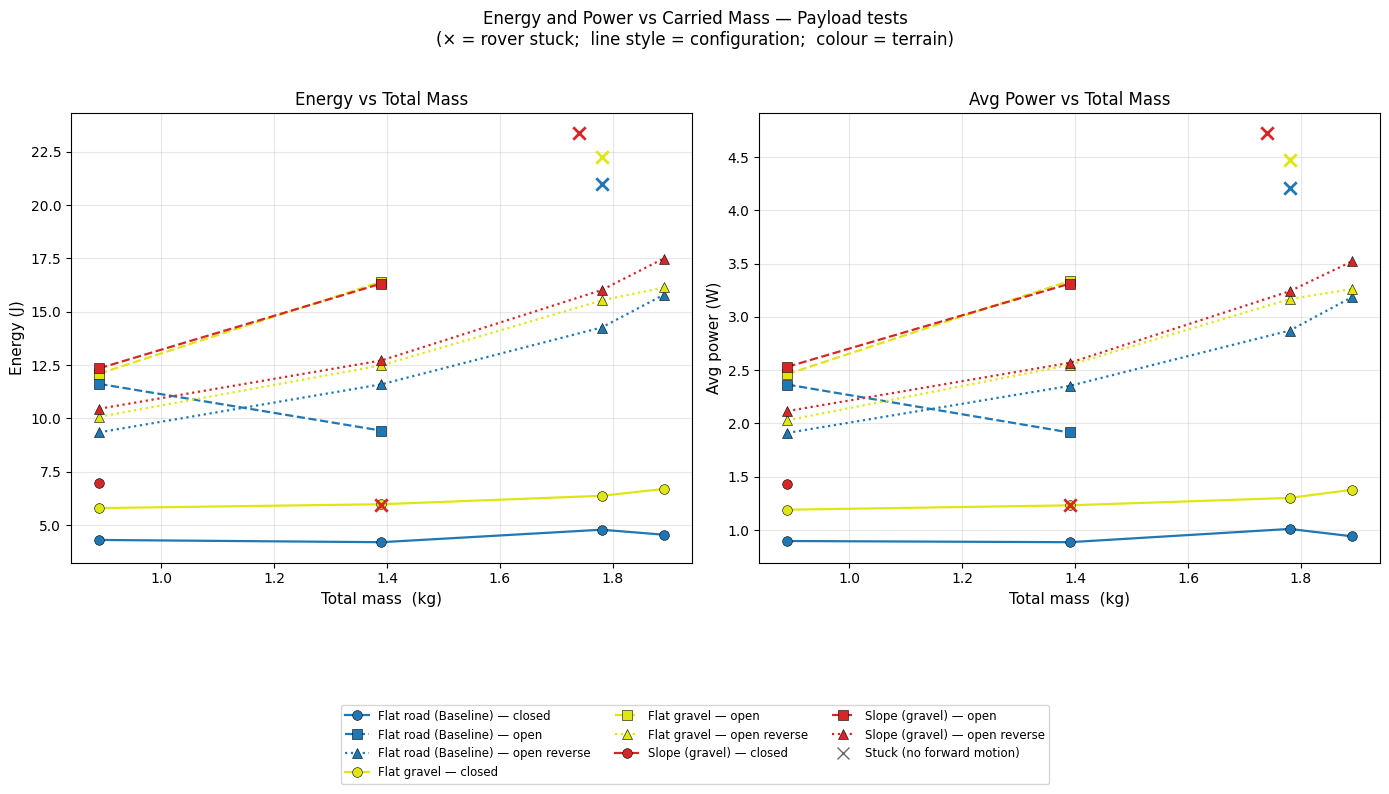

In [96]:
# ─── ENERGY vs MASS  &  POWER vs MASS — PLOTS ───────────────────────────────
#
# X-axis : total carried mass (kg)  — rover + added payload
# Y-axis : Energy (J) [left plot]  /  Avg power (W) [right plot]
#
# Each terrain × configuration pair is one series.
# Points within a series are connected by a line to show how consumption
# scales as payload increases.
# Stuck runs are shown as isolated ✕ markers (no connecting line).

terrain_colors_p = {
    "baseline": "#1f77b4",
    "flat":     "#dfe612",
    "slope":    "#d62728",
}
config_styles = {
    "closed":       {"ls": "-",  "marker": "o"},
    "open":         {"ls": "--", "marker": "s"},
    "open_reverse": {"ls": ":",  "marker": "^"},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, (metric, ylabel) in zip(
    axes,
    [("energy_J", "Energy (J)"), ("power_avg_W", "Avg power (W)")],
):
    # ── one series per terrain × config ──────────────────────────────────────
    for terrain_key in PAYLOAD_TERRAIN_ORDER:
        for config in CONFIG_ORDER:
            subset = (
                payload_summary[
                    (payload_summary["terrain_key"] == terrain_key) &
                    (payload_summary["config"]       == config)
                ]
                .sort_values("total_mass_kg")
            )
            if subset.empty:
                continue

            color  = terrain_colors_p[terrain_key]
            style  = config_styles[config]
            label  = f"{payload_terrain_labels[terrain_key]} — {config.replace('_', ' ')}"

            ok     = subset[~subset["failed"]]
            failed = subset[ subset["failed"]]

            # Connected line through successful points
            if len(ok) >= 1:
                ax.plot(
                    ok["total_mass_kg"], ok[metric],
                    color=color, linestyle=style["ls"],
                    marker=style["marker"], markersize=7,
                    linewidth=1.6, label=label,
                    markeredgecolor="k", markeredgewidth=0.4,
                )

            # Isolated ✕ for stuck runs
            if not failed.empty:
                ax.scatter(
                    failed["total_mass_kg"], failed[metric],
                    color=color, marker="x", s=80,
                    linewidths=2.0, zorder=5,
                    label=f"{label} [stuck]" if ok.empty else None,
                )

    ax.set_xlabel("Total mass  (kg)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Energy vs Total Mass", fontsize=12)
axes[1].set_title("Avg Power vs Total Mass", fontsize=12)

# ── Shared legend ─────────────────────────────────────────────────────────────
handles, labels_leg = axes[0].get_legend_handles_labels()
# De-duplicate (open_reverse may appear from both subplots)
seen = {}
for h, l in zip(handles, labels_leg):
    if l and l not in seen:
        seen[l] = h

# Add a ✕ entry for stuck runs
stuck_handle = plt.Line2D([0], [0], marker="x", color="dimgray",
                           linestyle="None", markersize=9, linewidth=2,
                           label="Stuck (no forward motion)")
seen["Stuck (no forward motion)"] = stuck_handle

fig.legend(
    seen.values(), seen.keys(),
    loc="lower center", bbox_to_anchor=(0.5, -0.28),
    ncol=3, fontsize=8.5, frameon=True,
)
fig.suptitle(
    "Energy and Power vs Carried Mass — Payload tests\n"
    "(× = rover stuck;  line style = configuration;  colour = terrain)",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

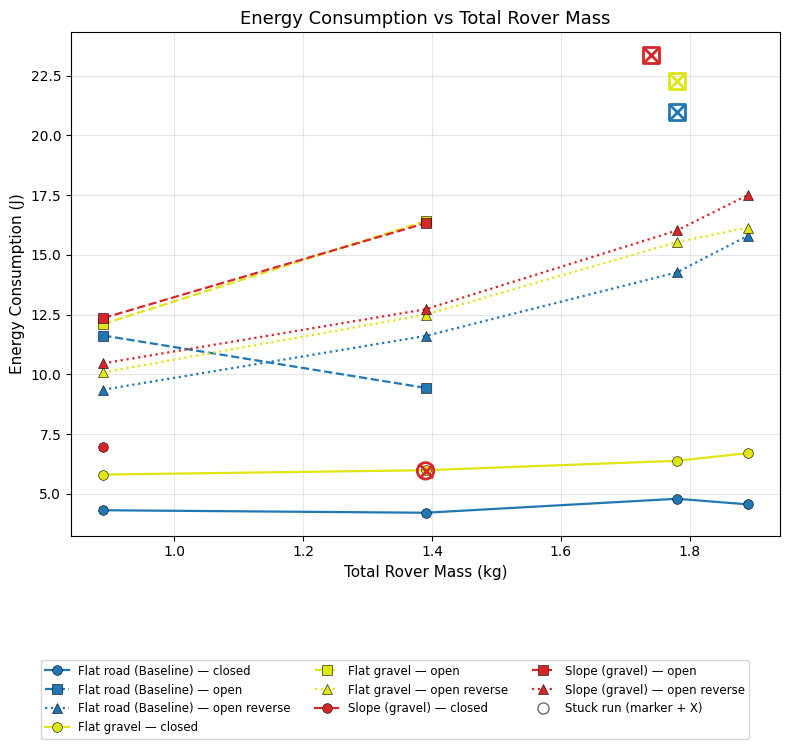

In [97]:
# ─── ENERGY vs MASS ──────────────────────────────────────────────────────────

terrain_colors_p = {
    "baseline": "#1f77b4",
    "flat":     "#dfe612",
    "slope":    "#d62728",
}

config_styles = {
    "closed":       {"ls": "-",  "marker": "o"},
    "open":         {"ls": "--", "marker": "s"},
    "open_reverse": {"ls": ":",  "marker": "^"},
}

fig, ax = plt.subplots(figsize=(8, 6))

metric = "energy_J"

for terrain_key in PAYLOAD_TERRAIN_ORDER:
    for config in CONFIG_ORDER:

        subset = (
            payload_summary[
                (payload_summary["terrain_key"] == terrain_key) &
                (payload_summary["config"] == config)
            ]
            .sort_values("total_mass_kg")
        )

        if subset.empty:
            continue

        color = terrain_colors_p[terrain_key]
        style = config_styles[config]

        label = (
            f"{payload_terrain_labels[terrain_key]}"
            f" — {config.replace('_', ' ')}"
        )

        ok = subset[~subset["failed"]]
        failed = subset[subset["failed"]]

        # Successful runs
        if len(ok) >= 1:
            ax.plot(
                ok["total_mass_kg"],
                ok[metric],
                color=color,
                linestyle=style["ls"],
                marker=style["marker"],
                markersize=7,
                linewidth=1.6,
                label=label,
                markeredgecolor="k",
                markeredgewidth=0.4,
            )

        # Failed runs = marker + X
        if not failed.empty:

            ax.scatter(
                failed["total_mass_kg"],
                failed[metric],
                facecolors="none",
                edgecolors=color,
                marker=style["marker"],
                s=140,
                linewidths=2.0,
                zorder=5,
            )

            ax.scatter(
                failed["total_mass_kg"],
                failed[metric],
                color=color,
                marker="x",
                s=90,
                linewidths=2.0,
                zorder=6,
            )

ax.set_xlabel("Total Rover Mass (kg)", fontsize=11)
ax.set_ylabel("Energy Consumption (J)", fontsize=11)
ax.set_title("Energy Consumption vs Total Rover Mass", fontsize=13)

ax.grid(True, alpha=0.3)

handles, labels_leg = ax.get_legend_handles_labels()

seen = {}
for h, l in zip(handles, labels_leg):
    if l and l not in seen:
        seen[l] = h

stuck_handle = plt.Line2D(
    [0], [0],
    marker="o",
    markerfacecolor="none",
    markeredgecolor="dimgray",
    linestyle="None",
    markersize=8,
    label="Stuck run",
)

seen["Stuck run (marker + X)"] = stuck_handle

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    fontsize=8.5,
    frameon=True,
)

plt.tight_layout()
plt.show()

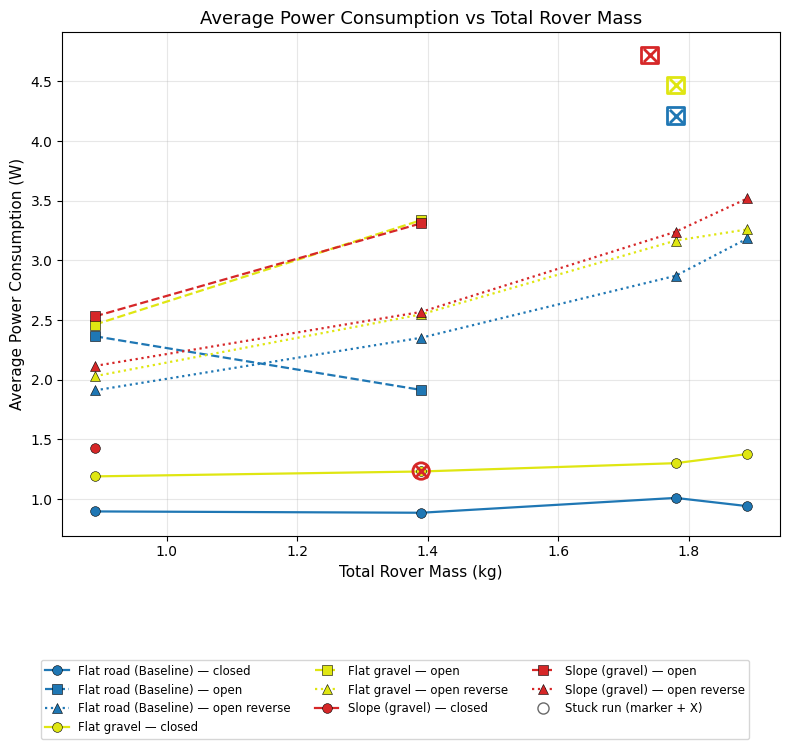

In [98]:
# ─── POWER vs MASS ───────────────────────────────────────────────────────────

terrain_colors_p = {
    "baseline": "#1f77b4",
    "flat":     "#dfe612",
    "slope":    "#d62728",
}

config_styles = {
    "closed":       {"ls": "-",  "marker": "o"},
    "open":         {"ls": "--", "marker": "s"},
    "open_reverse": {"ls": ":",  "marker": "^"},
}

fig, ax = plt.subplots(figsize=(8, 6))

metric = "power_avg_W"

for terrain_key in PAYLOAD_TERRAIN_ORDER:
    for config in CONFIG_ORDER:

        subset = (
            payload_summary[
                (payload_summary["terrain_key"] == terrain_key) &
                (payload_summary["config"] == config)
            ]
            .sort_values("total_mass_kg")
        )

        if subset.empty:
            continue

        color = terrain_colors_p[terrain_key]
        style = config_styles[config]

        label = (
            f"{payload_terrain_labels[terrain_key]}"
            f" — {config.replace('_', ' ')}"
        )

        ok = subset[~subset["failed"]]
        failed = subset[subset["failed"]]

        # Successful runs
        if len(ok) >= 1:
            ax.plot(
                ok["total_mass_kg"],
                ok[metric],
                color=color,
                linestyle=style["ls"],
                marker=style["marker"],
                markersize=7,
                linewidth=1.6,
                label=label,
                markeredgecolor="k",
                markeredgewidth=0.4,
            )

        # Failed runs = marker + X
        if not failed.empty:

            ax.scatter(
                failed["total_mass_kg"],
                failed[metric],
                facecolors="none",
                edgecolors=color,
                marker=style["marker"],
                s=140,
                linewidths=2.0,
                zorder=5,
            )

            ax.scatter(
                failed["total_mass_kg"],
                failed[metric],
                color=color,
                marker="x",
                s=90,
                linewidths=2.0,
                zorder=6,
            )

ax.set_xlabel("Total Rover Mass (kg)", fontsize=11)
ax.set_ylabel("Average Power Consumption (W)", fontsize=11)
ax.set_title("Average Power Consumption vs Total Rover Mass", fontsize=13)

ax.grid(True, alpha=0.3)

handles, labels_leg = ax.get_legend_handles_labels()

seen = {}
for h, l in zip(handles, labels_leg):
    if l and l not in seen:
        seen[l] = h

stuck_handle = plt.Line2D(
    [0], [0],
    marker="o",
    markerfacecolor="none",
    markeredgecolor="dimgray",
    linestyle="None",
    markersize=8,
    label="Stuck run",
)

seen["Stuck run (marker + X)"] = stuck_handle

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    fontsize=8.5,
    frameon=True,
)

plt.tight_layout()
plt.show()

COST OF TRANSPORT


,Terrain,Config,Added (g),Total mass (g),Energy (J),Distance (m),CoT,Note
0,Flat road (Baseline),closed,0,890,4.304,0.566,0.872,ok
1,Flat road (Baseline),closed,500,1390,4.199,0.566,0.544,ok
2,Flat road (Baseline),closed,890,1780,4.784,0.613,0.447,ok
3,Flat road (Baseline),closed,1000,1890,4.550,0.566,0.434,ok
4,Flat road (Baseline),open,0,890,11.621,1.037,1.284,ok
5,Flat road (Baseline),open,500,1390,9.428,0.346,2.001,ok
6,Flat road (Baseline),open,890,1780,20.985,NaN,NaN,stuck — no locomotion
7,Flat road (Baseline),open_reverse,0,890,9.351,0.943,1.136,ok
8,Flat road (Baseline),open_reverse,500,1390,11.602,0.943,0.903,ok
9,Flat road (Baseline),open_reverse,890,1780,14.264,0.943,0.867,ok


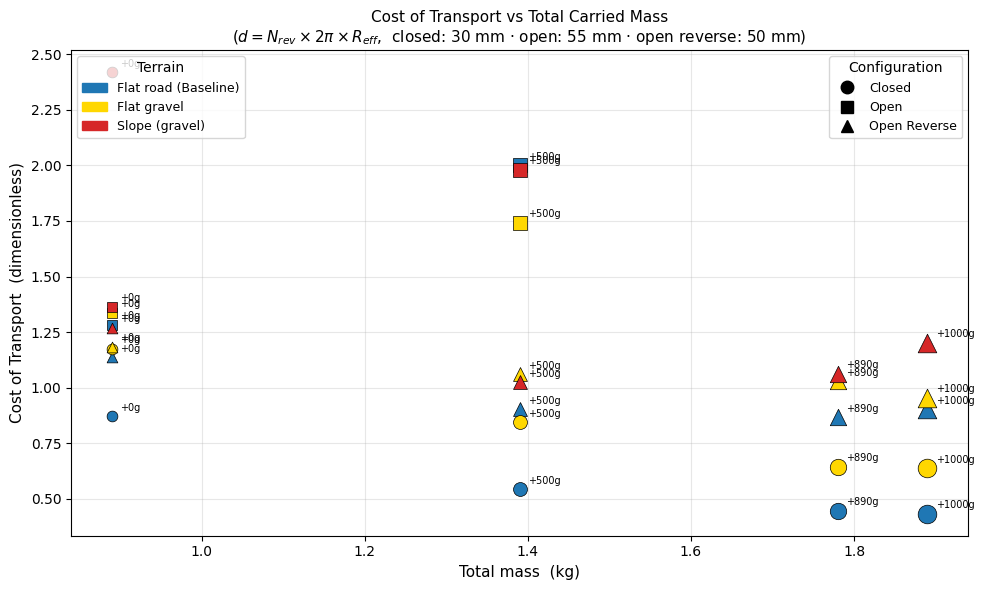

In [100]:
# ─── COST OF TRANSPORT (CoT) ────────────────────────────────────────────────
#
# CoT = E / (m · g · d)   [dimensionless]
#
#   E = energy consumed (J)  |  m = total mass (kg)
#   g = 9.81 m/s²            |  d = distance (m) = N_rev × 2π × R_eff

G = 9.81  # m/s²

# ── Distances computed from video rotation counts ────────────────────────────
# d = N_rev × 2π × R_eff   (R_eff: closed=30mm, open=55mm, open_reverse=50mm)
distances_m = {
    # ── Flat road (Baseline) ─────────────────────────────────────────────────
    ("baseline", "closed",        0):    0.5655,   # 3.00 rev × 2π × 30 mm
    ("baseline", "closed",      500):    0.5655,   # 3.00 rev
    ("baseline", "closed",      890):    0.6126,   # 3.25 rev
    ("baseline", "closed",     1000):    0.5655,   # 3.00 rev
    ("baseline", "open",          0):    1.0367,   # 3.00 rev × 2π × 55 mm
    ("baseline", "open",        500):    0.3456,   # 1.00 rev
    # open +890 g and +1000 g : stuck — belt skipped, no distance
    ("baseline", "open_reverse",  0):    0.9425,   # 3.00 rev × 2π × 50 mm
    ("baseline", "open_reverse", 500):   0.9425,   # 3.00 rev
    ("baseline", "open_reverse", 890):   0.9425,   # 3.00 rev
    ("baseline", "open_reverse",1000):   0.9425,   # 3.00 rev
    # ── Flat gravel ───────────────────────────────────────────────────────────
    ("flat",     "closed",        0):    0.5655,   # 3.00 rev × 2π × 30 mm
    ("flat",     "closed",      500):    0.5184,   # 2.75 rev
    ("flat",     "closed",      890):    0.5655,   # 3.00 rev
    ("flat",     "closed",     1000):    0.5655,   # 3.00 rev
    ("flat",     "open",          0):    1.0367,   # 3.00 rev × 2π × 55 mm
    ("flat",     "open",        500):    0.6912,   # 2.00 rev
    # open +890 g and +1000 g : stuck
    ("flat",     "open_reverse",  0):    0.9739,   # 3.10 rev × 2π × 50 mm
    ("flat",     "open_reverse", 500):   0.8639,   # 2.75 rev
    ("flat",     "open_reverse", 890):   0.8639,   # 2.75 rev
    ("flat",     "open_reverse",1000):   0.9111,   # 2.90 rev
    # ── Slope (gravel) ────────────────────────────────────────────────────────
    ("slope",    "closed",        0):    0.3299,   # 1.75 rev × 2π × 30 mm
    # closed +500 g and above : stuck on slope
    ("slope",    "open",          0):    1.0367,   # 3.00 rev × 2π × 55 mm
    ("slope",    "open",        500):    0.6048,   # 1.75 rev
    # open +890 g and +1000 g : stuck
    ("slope",    "open_reverse",  0):    0.9425,   # 3.00 rev × 2π × 50 mm
    ("slope",    "open_reverse", 500):   0.9111,   # 2.90 rev
    ("slope",    "open_reverse", 890):   0.8639,   # 2.75 rev
    ("slope",    "open_reverse",1000):   0.7854,   # 2.50 rev
}


def compute_cot(energy_J, total_mass_kg, distance_m):
    return energy_J / (total_mass_kg * G * distance_m)


cot_rows = []
for _, row in payload_summary.iterrows():
    key  = (row["terrain_key"], row["config"], int(row["added_payload_g"]))
    dist = distances_m.get(key)

    if row["failed"]:
        note = "stuck — no locomotion"
        cot  = None
    elif dist is None:
        note = "⚠ distance not set"
        cot  = None
    else:
        cot  = compute_cot(row["energy_J"], row["total_mass_kg"], dist)
        note = "ok"

    cot_rows.append({
        "Terrain":        row["terrain"],
        "config":         row["config"],       # lowercase — needed for merge
        "Added (g)":      int(row["added_payload_g"]),
        "Total mass (g)": int(row["total_mass_g"]),
        "total_mass_kg":  row["total_mass_kg"],
        "terrain_key":    row["terrain_key"],
        "Energy (J)":     round(row["energy_J"], 4),
        "Distance (m)":   dist,
        "CoT":            round(cot, 4) if cot is not None else None,
        "Note":           note,
    })

cot_df = pd.DataFrame(cot_rows)

print("=" * 85)
print("COST OF TRANSPORT")
print("=" * 85)
display(
    cot_df[["Terrain","config","Added (g)","Total mass (g)",
            "Energy (J)","Distance (m)","CoT","Note"]]
    .rename(columns={"config":"Config"})
)

# ── Visual style (redefined here so this cell runs independently) ────────────
terrain_colors_p = {
    "baseline": "#1f77b4",   # blue
    "flat":     "#FFD700",   # yellow
    "slope":    "#d62728",   # red
}
config_markers_p = {
    "closed":       "o",
    "open":         "s",
    "open_reverse": "^",
}
payload_sizes_p = {0: 60, 500: 100, 890: 140, 1000: 180}

terrain_handles = [
    __import__('matplotlib.patches', fromlist=['Patch']).Patch(
        color=c, label=payload_terrain_labels[t])
    for t, c in terrain_colors_p.items()
]
config_handles = [
    __import__('matplotlib.pyplot', fromlist=['']).Line2D(
        [0],[0], marker=m, color='k', linestyle='None',
        markersize=9, label=c.replace('_',' ').title())
    for c, m in config_markers_p.items()
]

# ── Plot ──────────────────────────────────────────────────────────────────────
available_cot = cot_df.dropna(subset=["CoT"]).copy()
if available_cot.empty:
    print("\n[No CoT values available yet]")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    for _, r in available_cot.iterrows():
        color  = terrain_colors_p.get(r["terrain_key"], "#7f7f7f")
        marker = config_markers_p.get(r["config"], "D")
        size   = payload_sizes_p.get(int(r["Added (g)"]), 80)
        ax.scatter(
            r["total_mass_kg"], r["CoT"],
            s=size, marker=marker, color=color,
            edgecolors="k", linewidths=0.5, zorder=3,
        )
        ax.annotate(
            f'+{int(r["Added (g)"])}g',
            (r["total_mass_kg"], r["CoT"]),
            textcoords="offset points", xytext=(6, 4), fontsize=7,
        )

    leg1 = ax.legend(handles=terrain_handles, title="Terrain",
                     loc="upper left",  fontsize=9)
    ax.legend(handles=config_handles,  title="Configuration",
              loc="upper right", fontsize=9)
    ax.add_artist(leg1)
    ax.set_xlabel("Total mass  (kg)", fontsize=11)
    ax.set_ylabel("Cost of Transport  (dimensionless)", fontsize=11)
    ax.set_title(
        "Cost of Transport vs Total Carried Mass\n"
        r"($d = N_{rev} \times 2\pi \times R_{eff}$,  "
        "closed: 30 mm · open: 55 mm · open reverse: 50 mm)",
        fontsize=11,
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

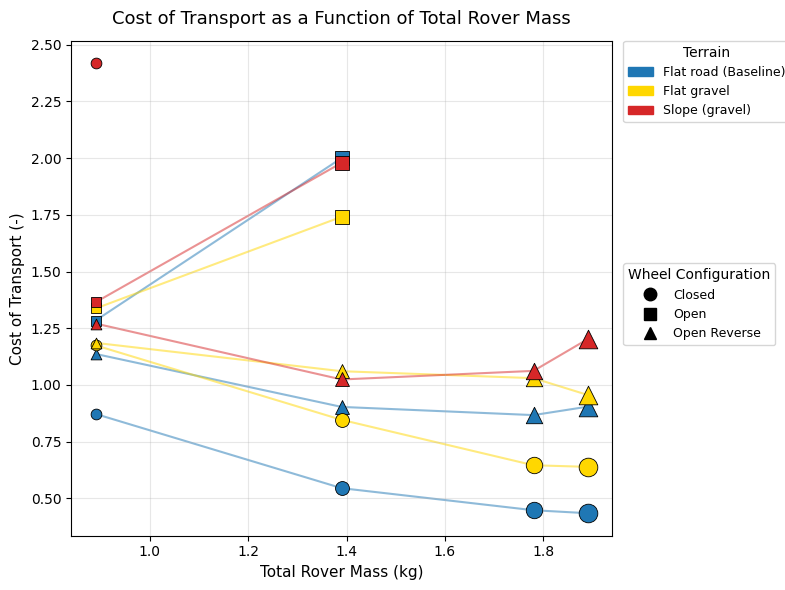

In [102]:
# ── Plot CoT ────────────────────────────────────────────────────────────────

available_cot = cot_df.dropna(subset=["CoT"]).copy()

if available_cot.empty:
    print("\n[No CoT values available yet]")

else:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw trend lines first
    for (terrain, config), grp in available_cot.groupby(["terrain_key", "config"]):

        grp = grp.sort_values("total_mass_kg")

        ax.plot(
            grp["total_mass_kg"],
            grp["CoT"],
            color=terrain_colors_p.get(terrain, "#7f7f7f"),
            linewidth=1.5,
            alpha=0.5,
            zorder=1,
        )

    # Draw scatter points
    for _, r in available_cot.iterrows():

        color = terrain_colors_p.get(r["terrain_key"], "#7f7f7f")
        marker = config_markers_p.get(r["config"], "D")
        size = payload_sizes_p.get(int(r["Added (g)"]), 80)

        ax.scatter(
            r["total_mass_kg"],
            r["CoT"],
            s=size,
            marker=marker,
            color=color,
            edgecolors="black",
            linewidths=0.6,
            zorder=3,
        )

    # Legends
    leg1 = ax.legend(
        handles=terrain_handles,
        title="Terrain",
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        borderaxespad=0,
        fontsize=9,
        title_fontsize=10,
    )

    leg2 = ax.legend(
        handles=config_handles,
        title="Wheel Configuration",
        bbox_to_anchor=(1.02, 0.55),
        loc="upper left",
        borderaxespad=0,
        fontsize=9,
        title_fontsize=10,
    )

    ax.add_artist(leg1)

    # Labels and title
    ax.set_xlabel("Total Rover Mass (kg)", fontsize=11)
    ax.set_ylabel("Cost of Transport (-)", fontsize=11)

    ax.set_title(
        "Cost of Transport as a Function of Total Rover Mass",
        fontsize=13,
        pad=12,
    )


    ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 0.80, 1])

    plt.show()